# **Padding in LLMs**



**Padding** means adding filler tokens to shorter sequences so that every sequence in a batch has the same length.
* LLMs process text as sequences of **tokens**.
* For speed, GPUs process many sequences at once in a **batch**, stored as a rectangular tensor (a grid of numbers)
   * Every row in that grid must be the same length, but real sentences vary in length. So shorter sentences are filled with a special **padding token** (often `[PAD]` or `<pad>`) until they match the longest one.
   




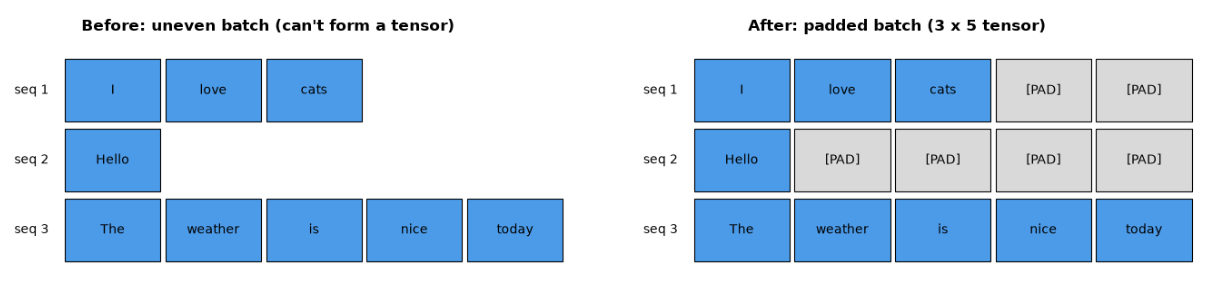

## **Tokenization**

After tokenization, each word becomes a number (token ID). Here we use a toy vocabulary and pad with ID `0`.

| Sentence | Token IDs |
|---|---|
| "I love cats" | `[101, 1045, 2293, 8870]` |
| "Hello" | `[101, 7592]` |
| "The weather is nice" | `[101, 1996, 4633, 2003, 3835]` |

The longest sequence has 5 tokens, so the others are padded to length 5.
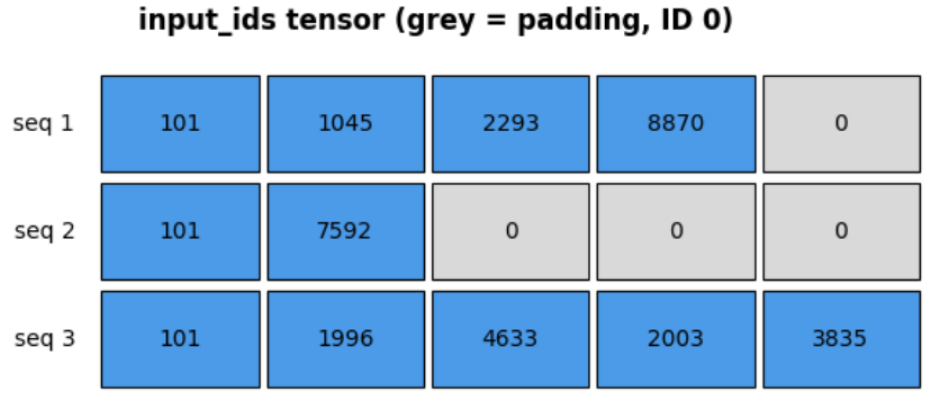

## **Attention Mask**

* Padding tokens carry no meaning, but a Transformer's attention layers look at **every** token in a sequence. If nothing stops them, padding tokens change the model's output.
* The fix is an **attention mask**: a tensor with the same shape as `input_ids`, containing:
- `1` = real token, attend to it
- `0` = padding, ignore it

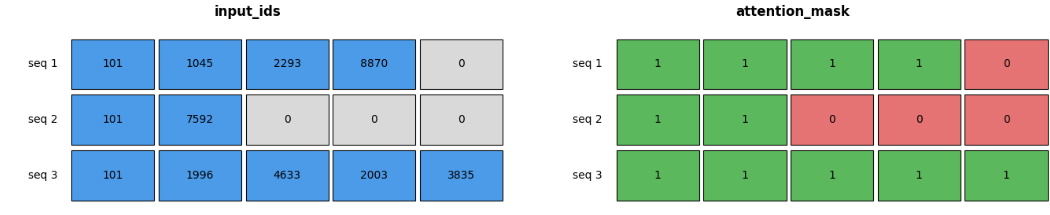

## **Padding Side**: Left vs Right

* **Left padding** (pads at the start) is preferred for **text generation** with decoder-only LLMs like GPT, LLaMA, or Mistral.
   * A decoder-only model predicts the next token from the **last position** in the row. With right padding, the last position of a short prompt is a `[PAD]` token, and the model was never trained to continue from padding
     * padding_side = "left"

* **Right padding** (pads at the end) is the standard choice for training and finetuning. Why training uses right padding?
  * padding_side = "right"
     * Training doesnt happen from the end, it is computing the whole system and expect real content from the start position.
  

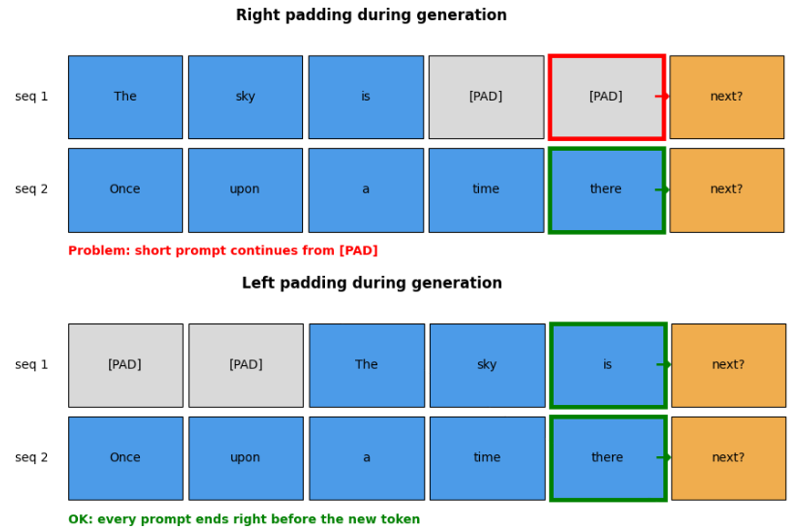

## Padding and EOS

* eos_token is a special token representing the end of a sentence.
* model.generate() needs to know whn to generate tokens, the model uses end of sequence tokens to indicate that a sequence of text has finished
  * We know that model predicts tokens, when the model see eos token, it signanls to the model that is should stop or that a sequence stop

In [13]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = "cpu"
model_id = "HuggingFaceTB/SmolLM2-135M-Instruct"    # small model

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(model_id,
                                             dtype=torch.float32).to(device)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

In [14]:
print("EOS token     :", tokenizer.eos_token)                  # <|im_end|>
print("EOS token ID  :", tokenizer.eos_token_id)               # 2
print("Model stops on:", model.generation_config.eos_token_id) # 2
print("PAD token   :", tokenizer.pad_token, tokenizer.pad_token_id)

# Ask for a longer answer
messages = [{"role": "user",
             "content": "Write three sentences about why cats make good pets."}]

text = tokenizer.apply_chat_template(messages,
                                     tokenize=False,
                                     add_generation_prompt=True)
inputs = tokenizer(text,
                   return_tensors="pt").to(device)

max_new = 200
outputs = model.generate(**inputs,
                         max_new_tokens=max_new,
                         do_sample=False,
                         repetition_penalty=1.2)

new_ids = outputs[0, inputs["input_ids"].shape[-1]:]

print("\nFull answer:")
print(repr(tokenizer.decode(new_ids, skip_special_tokens=False)))

# Show the last 8 tokens one by one
print("\nLast tokens:")
print(f"{'position':>8}  {'token ID':>8}  token")
start = max(0, len(new_ids) - 8)
for pos in range(start, len(new_ids)):
    tid = new_ids[pos].item()
    marker = "   <-- EOS" if tid == tokenizer.eos_token_id else ""
    print(f"{pos:>8}  {tid:>8}  {tokenizer.decode([tid])!r}{marker}")

print(f"\nGenerated {len(new_ids)} of max {max_new} tokens")
print("Stopped because of:", "EOS" if new_ids[-1].item() == tokenizer.eos_token_id else "max_new_tokens limit")

EOS token     : <|im_end|>
EOS token ID  : 2
Model stops on: 2
PAD token   : <|im_end|> 2

Full answer:
'Cats have been companions for humans since the dawn of time and continue to be beloved members of our families today due in part to their affectionate nature, which allows them to form strong bonds with owners who understand and care deeply for these intelligent creatures. Additionally, many people find that owning a cat brings joy through its companionship, as it provides unconditional love and attention from an early age without requiring extensive training or commitment over several years. Furthermore, research has shown that cats can provide emotional support during times of stress and anxiety while also offering practical assistance such as cleaning up after meals when they\'re hungry but not thirsty themselves. Overall, loving animals like cats bring immense happiness into homes where other family members may struggle to cope with life\'s challenges."<|im_end|>'

Last tokens:


## Resources

* [Padding and EOS Medium](https://medium.com/@khalandar.mokula/understanding-eos-token-and-pad-token-in-model-generate-config-huggingface-transformers-fef6845ed92a)
* [End of sequence](https://huggingface.co/docs/transformers/en/main_classes/tokenizer)

## Padding and Eos in practice with HuggingFace

* In Hugging Face, the **tokenizer** does the padding and builds the attention mask, so we only need to choose the settings.

Exampl 1

In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token     # GPT-2 has no pad token (see section 6)

texts = ["I love cats", "Hello", "The weather is nice today"]

enc = tokenizer(
    texts,
    padding=True,          # pad to the longest sequence in the batch
    truncation=True,       # cut sequences longer than max_length
    max_length=512,
    return_tensors="pt",   # return PyTorch tensors
)

print(enc["input_ids"])
print(enc["attention_mask"])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

tensor([[   40,  1842, 11875, 50256, 50256],
        [15496, 50256, 50256, 50256, 50256],
        [  464,  6193,   318,  3621,  1909]])
tensor([[1, 1, 1, 0, 0],
        [1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1]])


In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_id,
                                          padding_side="left")  # left for inference

tokenizer.pad_token = tokenizer.eos_token # I want pad equal eos

model = AutoModelForCausalLM.from_pretrained(model_id)

model.config.pad_token_id = tokenizer.eos_token_id    # tell the model which ID is padding

prompts = ["The sky is", "Once upon a time there was"]
inputs = tokenizer(prompts,
                   padding=True,
                   return_tensors="pt")

outputs = model.generate(
    **inputs,                          # passes input_ids AND attention_mask
    max_new_tokens=20,
    pad_token_id=tokenizer.eos_token_id,
)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

['The sky is the limit.\n\nThe sky is the limit.\n\nThe sky is the limit.\n', 'Once upon a time there was a great deal of confusion about the meaning of the word "fool." The word "fool']


## Why is this relevant?


**PADDING**
* When we do batching, the training step takes x example from different lenths
  1. These must be padded into rectangles.Behind the scene the data collector pads every batch into its on longest sequence
   * Thanks this DataCollatorForLanguageModeling
  2. processing_class = hf_tokenizer, this tell which token to pad, at this point the model MUST have a padding token, now if it doesnt the TRL finds the model EOS tokn and thoses the PAD=EOS

**EOS**
When model checks accuracy, or when it learns from it the completion
 * when learning is happening completion_only_loss = True
 * Completition of learning should stop at the classification yes or no
 * But what the model sees is "y" +EOS
   * Whn the modl is learning it is larning the labels and to stop right after it.

### Resources

* [Padding Info](https://huggingface.co/docs/transformers/main/en/pad_truncation)
* [Handling multiple sequences](https://huggingface.co/learn/llm-course/chapter2/5)
* [Token, Padding and More!](https://huggingface.co/docs/transformers/llm_tutorial)

# **Quantization**



**Model Computation**

* Model computation are done using floating-point numbers
* The precision of these number impact how accurately the model performs in different task such as training and inferences.
* Floating Point Representation: Mantissa, Exponent, and Sign. A floating-point number is made up of three parts:     
    * **The mantissa**
      * Mantissa: fraction significant digits more bits allocated here more accurate the number, precision
    * **The exponent**
      * Exponent the scale or range of the number, how far left or right it should be (how big or small)
    * **The sign bit**
      * The number sign, a whole bit just dedicated to know if the number is positive or negative
         * which direction to learn (increase or decrease the weight)

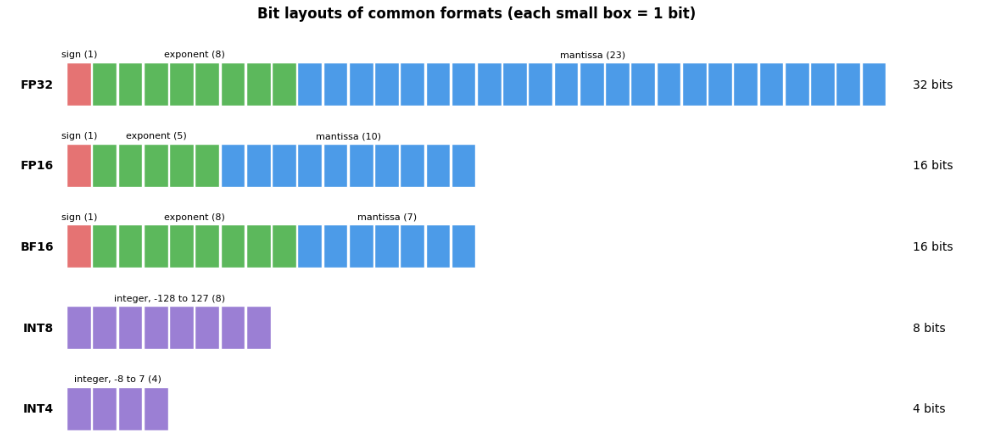

**Torch dtype** is the numeric precision of the models weights.
  * **FP32 (32-bit floating point):** This is the standard data type for many machine learning applications. It provides high precision, with 23 bits for the mantissa and 8 as exponent. However, the high precision comes at the cost of large memory usage and slower computations.
    
  * **FP16 (16-bit Floating Point)**: This is a compromise between speed and accuracy. It reduces memory usage and speeds up computations but sacrifices some precision.

  * **Bfloat16 (Brain Floating Point)**: This is a more recent development designed for deep learning tasks. It has 8 exponent bits but 7 mantissa bits. It keeps the exponent size from FP32 but reduces the mantissa size. Bfloat16 maintains the dynamic range of FP32, making it  useful for training large models, though it still comes with the trade-off of needing specialized hardware and being more expensive than lower-precision types like FP16.
    * ERROR: cannot use bf15 with T4 or even L4 GPU, to use bf16 the newer gpu are needed like A100

Why?
* LLM are big and hard to run, to do inferences on a 176B model the resources needed are about 8x 80GB A100 GPU ($15k each).
* We need a way to rduce these requirmnts while preserving models' performance.



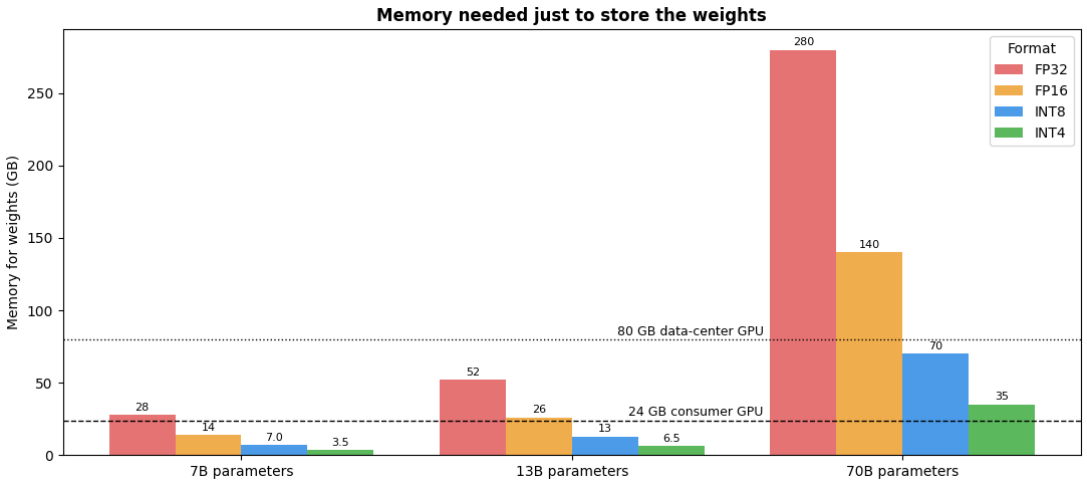

What it is?
* **Quantization** is a technique used to reduce the memory and computational requirements of a model by representing its weights and/or activations using lower-precision numerical formats, such as 8-bit integers (int8) or 4-bit values, instead of higher-precision formats such as 32-bit floating point (float32).
* **Quantization** is all about making your model lighter and faster without hurting its accuracy.
* It helps lower memory usage, model size and computational cost
   * **Weight Quantization**: compresses the train models parametres
   * **Activation Quantization**: compresses the output generated during inference

(Quantization converts the floats to integers, Dequantization converts them back for interpretation)

### References

* [A Gentle Introduction to 8bit Matrix Multiplication](https://huggingface.co/blog/hf-bitsandbytes-integration)
* [What is Quantization huggingface](https://huggingface.co/docs/optimum/en/concept_guides/quantization)
* [What is Quantization geeksforgeks](https://www.geeksforgeeks.org/deep-learning/quantization-in-deep-learning/)
* [The benefits of quantization](https://developer.nvidia.com/blog/model-quantization-concepts-methods-and-why-it-matters/)
* [Quantization and Training of Neural Network for Efficient Intger-Arithmtic-Only Inference](https://arxiv.org/pdf/1712.05877)
* [Quantization Types](https://huggingface.co/docs/hub/en/gguf#quantization-types)

## Quantization in practice with Hugging Face

Loading a model in 4-bit with bitsandbytes takes one config object. This needs an NVIDIA GPU (a free Colab T4 works) and:


Notice `bnb_4bit_compute_dtype`: the weights are **stored** in 4-bit, but they are dequantized to BF16 on the fly for the calculations. That's why quantization mostly saves memory rather than changing the model's math.



In [20]:
#%pip install transformers accelerate bitsandbytes
%pip install -q "trl==1.13.0" "transformers==5.17.0" "peft==0.21.0" accelerate datasets "bitsandbytes>=0.46.1"

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig


model_id  ="HuggingFaceTB/SmolLM2-135M-Instruct"
model = AutoModelForCausalLM.from_pretrained(model_id,
                                             device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_id)

print(f"Memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Memory footprint: 0.27 GB


In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",             # NormalFloat 4
    bnb_4bit_use_double_quant=True,        # also quantize the block scales
    bnb_4bit_compute_dtype=torch.bfloat16, # dequantize to BF16 for the calculation
)


model_id  ="HuggingFaceTB/SmolLM2-135M-Instruct"
model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_id)

print(f"Memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Memory footprint: 0.11 GB


# **Parameter-Efficient Fine-Tunning (PEFT): LoRA and QLoRA**

**Recap**
* An LLM is first pretrained on a huge amount of general text, this process teaches the model language and gnral knowledge, the resuls is set of weights, billions of number stored in big matrices (can be representd as W).

So What is **Finetuning**?
* Fine-tuning means taking that pretrained model and continuing to train it on a smaller, specific task.
* Finetuning changes the weight. If originals weights are W then the finetune weights are W+deltaW


## **Full finetuning too expensive**

* In **full fine-tuning**, every weight in the model is updated. With the usual Adam optimizer and mixed precision, each trainable parameter needs roughly
* Every weight is changed directly, so after training W has ben overwritten with new values

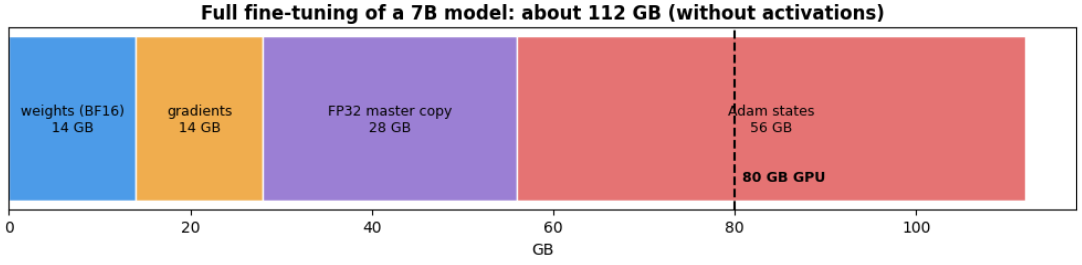

* So a 7B model needs about **112 GB** just for these, before counting activations. That's more than a single 80 GB GPU.
  * Weights (BF16), stored in 16bits which is about 2bytes, 7Bx2bytes = 15GB, just running the model
  * Gradients, 2bytes, 14GB. Gradient tells the model which directions should the weight move
    * loss smaller? how big?
    * sign tells the direction(increase of decreases)
    * The size is about how much the weight afects the mistakes

  * FP32 master copy, 4bytes. The optimizer does is to keep a copy of the model, applies the tiny updates to that copy then it rounds it to th bf16 for a 7b this is 7B x4 bytes = 28GB

  * Adam optimizer, the optimizer is the rules that decides how to turn gradients, adams needs around 8bytes per weight, 56 GB.

  

## What is LoRA?

* LoRA (Low-Rank Adaptation) is a parameter-efficient fine-tuning method for large neural networks, introduced by Hu et al. (2021).
  * It freezes the pretrained weights of a model and represents the weight update learned during fine-tuning as the product of two small, trainable low-rank matrices.
* W is frozen and never changes. Only the new A and B matrices are trained and added on top.
* LoRA only needs the weights...FROZEN...
* Th other three pieces, gradients, master copy, Adam state are not needed since LoRA does not change the orignal weights directly

* LoRA only needs the A and B skinny matrices which are about .6GB
* If using QLoRA, it shirks the frozen weights lets says from 14GB to about 3.6 GB by storing them in 4bit.

## Key Ideas of LoRA

Fine-tuning changes a weight matrix $W$ into a new one:

$$W_{\text{new}} = W + \Delta W$$

In full fine-tuning, $\Delta W$ has the same size as $W$. For a $4096 \times 4096$ layer, that's about 16.8 million numbers to learn.

LoRA **freezes** $W$ and writes the change as the product of two thin matrices:

$$\Delta W = B \, A \qquad B: d \times r, \quad A: r \times k$$

where the **rank** $r$ is small (for example 8 or 16). For the same $4096 \times 4096$ layer with $r = 16$:

$$4096 \times 16 + 16 \times 4096 = 131{,}072 \text{ numbers} \quad (\text{about } 0.8\% \text{ of the layer})$$

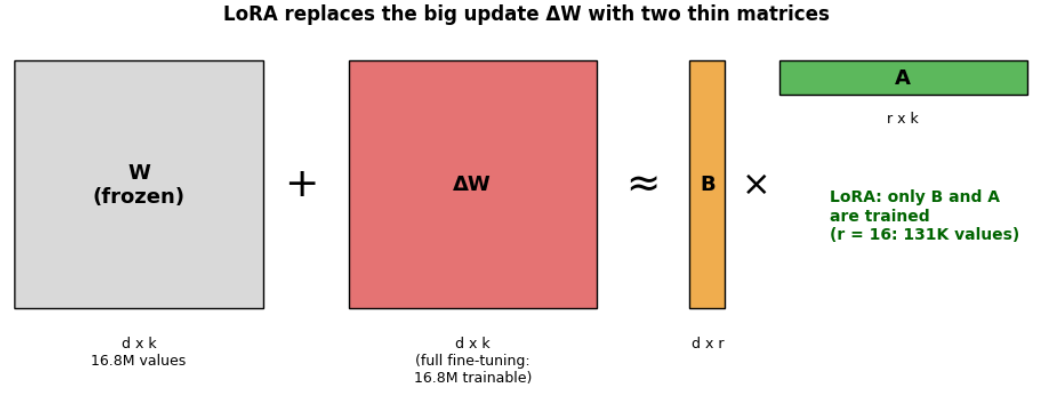

The shape of W
* W is d x k (d is output and K in input)
* A is r x k (takes the layer input)
* B is d x r (takes the ouput size layer)
  * A and B ar created by LoRA
  * training fills in their values and then are saved as adapters
  * We load th orignal base modl and attach those savd A and B matrices to it

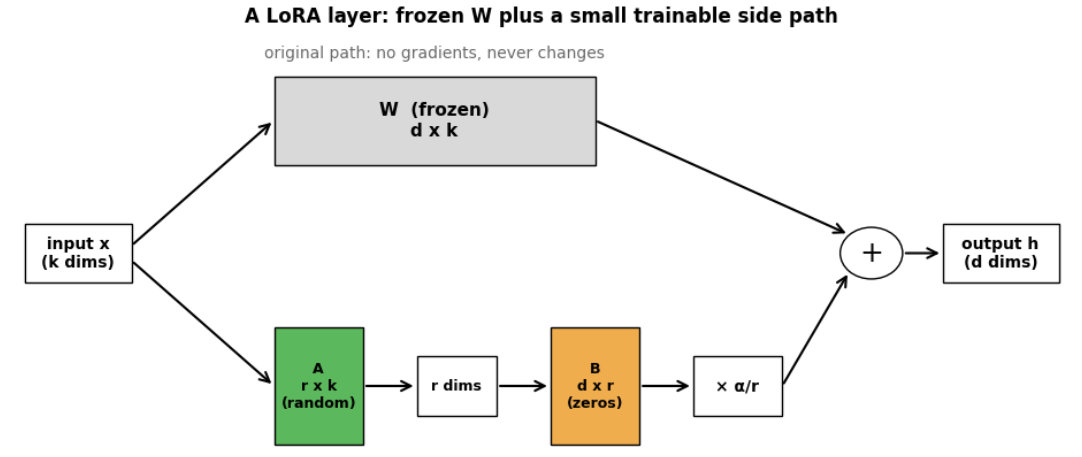

**Just a quick intro**
* r is a vector of r number, we can change the value
  * if r = 16, if input features are many it squeezes into 16 features

* scale =alpha/r
  * lora_alpha/r
    * it controls how strong the LoRA updates affect the output
       * large alpha/r mean LoRA has a bigger effect, model changes faster during training
       * Smaller alpha/r smaller effct, changes are more gradual

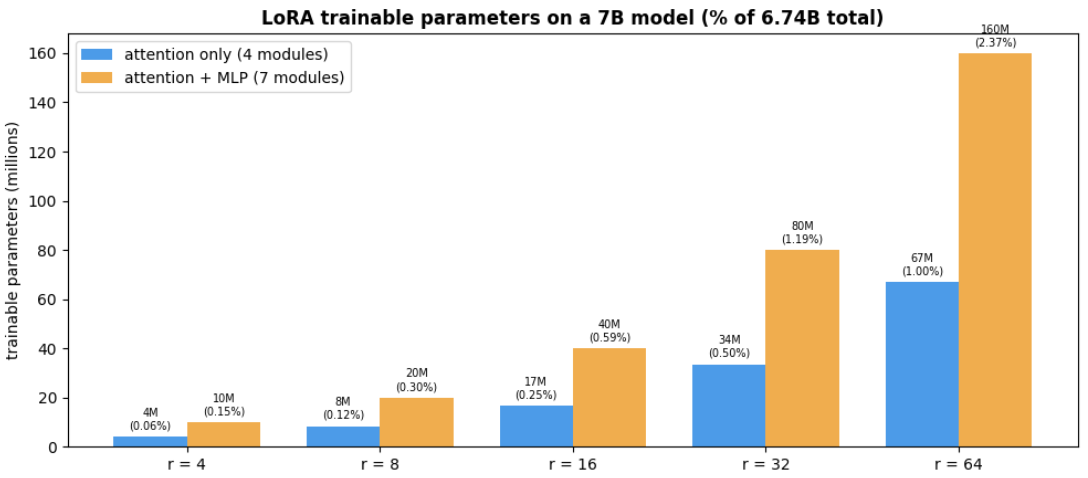

## QLoRA

Outliers
* **Double quantization** (used in QLoRA) reduces this by quantizing the scales themselves. Another approach, **LLM.int8()**, keeps outliers in 16-bit and quantizes everything else to 8-bit.

### References

Papers
* [LoRA: Low-Rank Adaptation of Large Language Models (Hu et al., 2021)](https://arxiv.org/abs/2106.09685)
* [QLoRA: Efficient Finetuning of Quantized LLMs (Dettmers et al., 2023)](https://arxiv.org/abs/2305.14314)

* [QLoRA (Quantized Low-Rank Adapter) geksforgeeks](https://www.geeksforgeeks.org/deep-learning/qlora-quantized-low-rank-adapter/)

# Code Here

In [3]:
%pip install -q "trl==1.13.0" "transformers==5.17.0" "peft==0.21.0" accelerate datasets "bitsandbytes>=0.46.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 61.2 MB/s eta 0:00:00
^C


In [2]:
%pip install -U transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 37.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0


In [1]:
import os
from datetime import datetime
from dotenv import load_dotenv
from pathlib import Path
from huggingface_hub import login
import torch
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

In [2]:
from pathlib import Path
from dotenv import load_dotenv
import torch

load_dotenv()

USER = "colab"

if USER == "local":
    WORKING_DIR = Path(
        "/Users/brittneyhernandez/Library/CloudStorage/"
        "OneDrive-UniversityofConnecticut/AIME-con"
    )
    DATA_DIR = WORKING_DIR / "data"

elif USER == "hpc":
    WORKING_DIR = Path.cwd()
    DATA_DIR = WORKING_DIR / "data"

elif USER == "colab":
    from google.colab import drive

    drive.mount("/content/drive/")
    WORKING_DIR = Path("/content/drive/MyDrive/AIMEcon_2026/aime-con3")
    DATA_DIR = WORKING_DIR / "data"

RESULTS_DIR = WORKING_DIR / "results"

DATA_SOURCE = "train"   # train, validate, test
DESCRIPTION = "learn5e-5"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_STATE = 42

Mounted at /content/drive/


In [3]:
print("USER:", USER)
print("WORKING_DIR:", WORKING_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("DEVICE:", DEVICE)

USER: colab
WORKING_DIR: /content/drive/MyDrive/AIMEcon_2026/aime-con3
DATA_DIR: /content/drive/MyDrive/AIMEcon_2026/aime-con3/data
RESULTS_DIR: /content/drive/MyDrive/AIMEcon_2026/aime-con3/results
DEVICE: cuda


In [4]:
print(f"\nUsing device: {DEVICE}")
if DEVICE == "cuda":
    if torch.cuda.is_bf16_supported():
        PRECISION = torch.bfloat16
    else:
        PRECISION = torch.float16
    print(torch.cuda.get_device_name(0))
else:
    raise RuntimeError("No GPU found: 4-bit QLoRA training requires CUDA.")


Using device: cuda
NVIDIA A100-SXM4-40GB


In [7]:
# float32 = full precision for CPU
# can use bfloat16 if cuda is available (float for cpu, bfloat for gpu)


In [5]:
# ---- get data ----
path_to_train = DATA_DIR / "train.xlsx"
train = pd.read_excel(path_to_train)
word_counts = train["text"].str.split(" ").str.len()

max_utterance_len = word_counts.max()
path_to_dev = DATA_DIR / "dev.xlsx"
dev = pd.read_excel(path_to_dev)

In [6]:
train


,index,filename,speaker,timestamp,text,prompt_hima,prompt_kelsi,prompt_brittney,code_human
0,78,15309888_1.xlsx,Student 3,21:16,102030 4050 6070 8090 110 100 1100 1200---,0,0,0,0
1,79,15309888_1.xlsx,Teacher,21:27,"Okay, so can you write your what your answer i...",1,1,1,1
2,80,15309888_1.xlsx,Student 6,21:45,113,0,0,0,0
3,81,15309888_1.xlsx,Teacher,21:46,How did you get because I don't see I don't se...,1,1,1,1
4,82,15309888_1.xlsx,Student 6,21:50,"I just, I just counted by tens, like I did yes...",0,0,0,0
...,...,...,...,...,...,...,...,...,...
3724,132,96286269_2.xlsx,Teacher,41:57,"Yeah. It well, it happens when there's 50, som...",1,1,1,1
3725,133,96286269_2.xlsx,Student,42:32,I put 50 tally marks and took 23 away.,0,0,0,0
3726,134,96286269_2.xlsx,Teacher,42:39,Okay,0,0,0,0
3727,135,96286269_2.xlsx,Student,42:40,And I got the answer 27,0,0,0,0


In [7]:
word_counts

,text
0,8.0
1,44.0
2,1.0
3,20.0
4,11.0
...,...
3724,78.0
3725,9.0
3726,1.0
3727,6.0


In [8]:
dev

,index,filename,speaker,timestamp,text,prompt_hima,prompt_kelsi,prompt_brittney,code_human
0,0,10861631_1.xlsx,Teacher,00:04,I'm going to place up and I need you to tell m...,1,1,1,1
1,1,10861631_1.xlsx,Student 1,02:19,Counted two plus two plus two equals ten,0,0,0,0
2,2,10861631_1.xlsx,Teacher,02:28,But what do you think they chose this way to s...,1,1,1,1
3,3,10861631_1.xlsx,Student 2,02:44,there's four boxes and then it's a different w...,0,0,0,0
4,4,10861631_1.xlsx,Teacher,02:52,"Oh, they made it a different way",0,0,0,0
...,...,...,...,...,...,...,...,...,...
3534,134,94759808_2.xlsx,Student,27:59,you can decompose by ...,0,0,0,0
3535,135,94759808_2.xlsx,Teacher,27:59,"Okay, I need you paying attention. So talking ...",1,1,1,1
3536,136,94759808_2.xlsx,Student,28:10,By taking apart and putting 50 plus two?,1,1,1,1
3537,137,94759808_2.xlsx,Teacher,28:20,"Okay, could you 50 plus two, why can't I just ...",1,1,1,1


In [9]:
not_prompt_train = train[train["code_human"] == 0]
prompt_train = train[train["code_human"] == 1]
minority_rows = min(len(not_prompt_train), len(prompt_train))

In [10]:
train_balanced = pd.concat([
    not_prompt_train.sample(n = minority_rows, random_state = RANDOM_STATE),
    prompt_train.sample(n = minority_rows, random_state = RANDOM_STATE),
    ]).sample(frac = 1, random_state = RANDOM_STATE).reset_index(drop = True)

In [11]:
print("\nSAMPLE SIZE\n")
print(f"n train: {len(train):,}\n{train['code_human'].value_counts()}\n")
print(f"n train balanced: {len(train_balanced):,}\n{train_balanced['code_human'].value_counts()}\n")
print(f"n dev: {len(dev):,}\n{dev['code_human'].value_counts()}\n")


SAMPLE SIZE

n train: 3,729
code_human
0    2002
1    1727
Name: count, dtype: int64

n train balanced: 3,454
code_human
0    1727
1    1727
Name: count, dtype: int64

n dev: 3,539
code_human
0    1901
1    1638
Name: count, dtype: int64



In [15]:
WORKING_DIR

PosixPath('/content/drive/MyDrive/AIMEcon_2026/aime-con3')

In [ ]:
# ---- get prompt codebook Best----
path_to_prompts = WORKING_DIR / "data_management" / "empirical_prompts_50.csv"
prompts = pd.read_csv(path_to_prompts).fillna("")
prompt_dictionary = prompts.set_index("prompt_id").to_dict(orient = "index")

def prompt_case(case, p):
    parts = [
        p["context"],
        p["task"],
        p["definition"],
    ]

    # only include the guidance header if any guidance was drawn
    if len(p["guidance"]) > 0:
        parts.append(p["format_guidance"])
        parts.append(p["guidance"].strip())

    parts.append(p["format_case"])
    parts.append(f"\n\"\"\"{case}\"\"\"\n")                 # <- the case goes here
    parts.append(p["format_local"])    # e.g. output format instructions

    return "\n\n".join(part for part in parts if part)

# choose which prompt to use
prompt_id = "baseline_c0t1d1g0"

In [ ]:
# choose which prompt to use
prompt_id = "baseline_c0t1d1g0"

prompt_template = prompt_case("CASE", prompt_dictionary[prompt_id])
print(f"\n\nPROMPT TEMPLATE: {prompt_id}\n{prompt_template}\n\n")

prompt_len = len(prompt_template.split(" "))

Baseline prompt 

In [12]:
# ---- get prompt codebook ----
# this is the baseline prompt
path_to_prompts = WORKING_DIR / "data_management" / "llm_codebook.xlsx"
prompts = pd.read_excel(path_to_prompts)
prompt_dictionary = prompts.set_index("id")["prompt"].to_dict()

def prompt_case(case, p):
    parts = [
        p["task_1"],
        p["definition_1"],
        p["format_case"],
        ]

    parts.append(f"\n\"\"\"{case}\"\"\"\n")
    parts.append(p["format_local"])

    return "\n\n".join(part for part in parts if part)

prompt_template = prompt_case("CASE", prompt_dictionary)
print(f"\n\nPROMPT TEMPLATE\n{prompt_template}\n\n")

prompt_len = len(prompt_template.split(" "))



PROMPT TEMPLATE
Classify the following utterance as yes or no based on whether it is a dialogic prompt.

A dialogic prompt is defined as an utterance that implies, encourages, requests, or expects a new speaker (or multiple new speakers) to make a verbal contribution.

Here is the utterance:


"""CASE"""


Output format:
- First, give a brief explanation (1 short sentence, under 20 words) justifying your answer.
- Then give your final answer as a yes or no surrounded by three backticks. For example, ```yes``` or ```no```




In [13]:
# ---- set up model ----
login(token = os.getenv("HF_TOKEN"))

# finetuning
# meta-llama/Llama-3.2-1B-Instruct
# meta-llama/Llama-3.2-3B-Instruct
# ibm-granite/granite-4.2-3b
# Qwen/Qwen2.5-7B-Instruct
# ibm-granite/granite-4.2-8b

In [18]:
PRECISION = torch.float16

In [14]:
MODEL = "meta-llama/Llama-3.2-1B-Instruct"
TASK = "text-generation"
TOKENS = 500
TEMPERATURE = 0.1



In [15]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_quant_type = "nf4",
    bnb_4bit_compute_dtype = PRECISION,
    bnb_4bit_use_double_quant = True,
    )

In [21]:
quantization_8bitconfig = BitsAndBytesConfig(
    load_in_8bit=True)

In [16]:
model = AutoModelForCausalLM.from_pretrained(MODEL,
                                             quantization_config = bnb_config, #quantization_8bitconfig, #bnb_config
                                             dtype = PRECISION, #dtype = torch.float16
                                             #dtype = torch.float16,
                                             token = os.getenv("HF_TOKEN"),
                                             device_map = "auto") # initate pipeline

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [17]:
# caches attention key/values. faster generation but conflic w gradient checkpoint
model.config.use_cache = False

In [18]:
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL, token = os.getenv("HF_TOKEN"))

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [19]:
hf_tokenizer.padding_side = "right"

model.config.pad_token_id = hf_tokenizer.eos_token_id

In [20]:
# see how much space the model occupies in memory
print(model.get_memory_footprint() / 1e9, "GB")

if getattr(model.config, "quantization_config", None) is not None:
    QUANTIZATION = model.config.quantization_config
else:
    QUANTIZATION = None

print("\n\nFINETUNING INFO")
print(f"Model: {MODEL} \nPrecision: {PRECISION} \nQuantization: {QUANTIZATION}")

# see the layers in the model
# print(model)

1.012011264 GB


FINETUNING INFO
Model: meta-llama/Llama-3.2-1B-Instruct 
Precision: torch.bfloat16 
Quantization: BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "bfloat16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}



In [ ]:
# claudia look here -- this function replaces the commented out function below
# the completion is just the label and then i add completion_only_loss to the sft config
def make_prompt_completion(row, tokenizer):
    label_str = "Yes" if row["code_human"] == 1 else "No"

    return {
        "prompt": [
            {"role": "user", "content": prompt_case(str(row["text"]), prompt_dictionary[prompt_id])},
            ],

        "completion": [
            {"role": "assistant", "content": label_str},
            ],
        }

In [22]:
train_hf = Dataset.from_list([
     make_prompt_completion(row, hf_tokenizer) for _, row in train_balanced.iterrows()
     ])

dev_hf = Dataset.from_list([
    make_prompt_completion(row, hf_tokenizer) for _, row in dev.iterrows()
    ])

In [23]:
train_hf

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 3454
})

In [24]:
train_hf[0]

{'prompt': [{'content': 'Classify the following utterance as yes or no based on whether it is a dialogic prompt.\n\nA dialogic prompt is defined as an utterance that implies, encourages, requests, or expects a new speaker (or multiple new speakers) to make a verbal contribution.\n\nHere is the utterance:\n\n\n"""It is-"""\n\n\nOutput format:\n- First, give a brief explanation (1 short sentence, under 20 words) justifying your answer.\n- Then give your final answer as a yes or no surrounded by three backticks. For example, ```yes``` or ```no```',
   'role': 'user'}],
 'completion': [{'content': 'No', 'role': 'assistant'}]}

##  The LoRA Hyperparameters

| Setting | What it controls | Typical values |
|---|---|---|
| `r` | How many patterns the update can learn. Higher = more capacity, more parameters | 8, 16, 32 |
| `lora_alpha` | Strength of the LoRA update: scale = `lora_alpha / r` | Often `2 * r` |
| `lora_dropout` | Randomly drops inputs to the LoRA path during training to reduce overfitting | 0.0 to 0.1 |
| `target_modules` | Which weight matrices get a LoRA adapter | Attention only, or attention + MLP |
| `task_type` | What kind of model head to set up | `CAUSAL_LM` for text generation / SFT |

r capability to learn
- a lower rank number means fewer paramters, less capacity to learn, less risk of overfitting
- a higher rank means more paramters, more capacity to learn, more risk of overfitting, can learn more complex patterns
- yes/no dataset r=8 should be wood or r=16

lora_alpha
- scaling, it controls how the LoRA update influences the final output
- if r=16, then alpha/r lora_alpha= 32/16 = 2.0
- if r= 32 but alpha 32, th update have less influece is 1
- convention is alpha= 2 x r
- Increasing alpha makes the adapter updates more aggressive, decreasing makes them more conservative.

lora_dropout=0.05
- randomly turn off 5% of adapter acivation during training, like a dropout
- prevent overfitting, if we see overfitting we can do .10

Target_modules
- which layers gt LoRA adapters injected. We are targetting all 7 projection layers
  * Attention layers is related to how the model decides what to focus on
    * q_proj, k_proj, v_proj, o_proj
  * MLP layers are where factual knowledge is stored
    * gate_proj, up_proj, down_proj

(removing the MLP layers and keping attention layers cuts trainable parameters in half and trains faster)

task_type = TaskType.CAUSAL_LM
- this tell PEFT what kind of model architecture this is
- CAUSAL_ML is for decoder-only moodel

In [31]:
#task_type = TaskType.CAUSAL_LM,
#    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",


This is a different type of accuracy than

In [32]:
TaskType.SEQ_CLS,

(<TaskType.SEQ_CLS: 'SEQ_CLS'>,)

In [ ]:
lora_config = LoraConfig(
    r = 16, # rank of the adapter TRY: 8
    lora_alpha = 32, # multiplier, usually 2*r
    lora_dropout = 0.05, # TRY: more regularization .10
    bias = "none",
    task_type = TaskType.SEQ_CLS, #task_type = TaskType.CAUSAL_LM,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"]
)

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing = True)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


path_to_output = RESULTS_DIR / "finetune"
sft_config = SFTConfig(
    output_dir = path_to_output,
    completion_only_loss = True, # This only checks accuracy on the completion aka the y/n label
    num_train_epochs = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 32,
    gradient_accumulation_steps = 1,
    warmup_steps = 10,
    learning_rate = 2e-4, # TRY: slow down learning rate 1e-4 or 5e-5 (slower), 
    max_grad_norm = 0.3,
    fp16 = PRECISION == torch.float16,
    bf16 = PRECISION == torch.bfloat16,
    logging_steps = 10,
    eval_strategy = "steps",
    eval_steps = 20,
    save_strategy = "steps",
    save_steps = 20,
    save_total_limit = 3,
    load_best_model_at_end = True,
    metric_for_best_model = "eval_loss", # TRY? f1 or kappa
    # greater_is_better = True, # need this if using f1 or kappa
    report_to = "none",
    max_length = int((max_utterance_len + prompt_len) * 1.5) + 150, # claudia look here
    optim = "paged_adamw_8bit", # "adamw_torch",
)

trainer = SFTTrainer(
    model = model,
    args = sft_config,
    train_dataset = train_hf,
    eval_dataset = dev_hf,
    processing_class = hf_tokenizer,
    callbacks = [EarlyStoppingCallback(early_stopping_patience = 4)]
)

trainer.train()

path_to_finetuned_model = RESULTS_DIR / f'{MODEL}_FT_{DESCRIPTION}'
trainer.save_model(path_to_finetuned_model)

trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


Tokenizing train dataset:   0%|          | 0/3454 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/3454 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/3454 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/3454 [00:00<?, ? examples/s]

...

Building labels for eval dataset:   0%|          | 0/3539 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/3539 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/3539 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
20,0.297899,0.258167,0.196343,67548.000000,0.870992


* need to check for the inferences in the dev accuracy

In [ ]:
# Save finetuned model to Drive 
path_to_finetuned_model = RESULTS_DIR / f"finetune_{DESCRIPTION}"
trainer.save_model(path_to_finetuned_model)
hf_tokenizer.save_pretrained(path_to_finetuned_model)
print(f"Model saved to: {path_to_finetuned_model}")

In [ ]:
path_to_finetuned_model = RESULTS_DIR / f"finetune_{DESCRIPTION}"
path_to_finetuned_model

In [ ]:
from peft import PeftModel

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)
path_to_finetuned_model = "hernandezb3/aimecon-base"

model = PeftModel.from_pretrained(base_model, path_to_finetuned_model)
hf_tokenizer = AutoTokenizer.from_pretrained(path_to_finetuned_model)

# Testing

In [ ]:
test_df  = pd.read_excel(DATA_DIR / "test.xlsx")
test_df

In [ ]:
SAMPLE_SIZE = 30
sample = test_df.sample(n = SAMPLE_SIZE, ignore_index = True)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score

In [ ]:
# ---- Reuse model already in memory ----
model_inf = model
model_inf.eval()

hf_tokenizer.padding_side = "left"

# ---- Inference function ----
def predict_batch(texts, batch_size=32):
    predictions = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        prompt_texts = []

        for text in batch:
            messages = [
                {
                    "role": "user",
                    "content": prompt_case(
                        str(text),
                        prompt_dictionary[prompt_id]
                    )
                },
            ]

            prompt_texts.append(
                hf_tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True
                )
            )

        inputs = hf_tokenizer(
            prompt_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=2000,
        ).to(model_inf.device)

        with torch.no_grad():
            outputs = model_inf.generate(
                **inputs,
                max_new_tokens=5,
                do_sample=False,
                pad_token_id=hf_tokenizer.eos_token_id,
            )

        input_len = inputs["input_ids"].shape[1]

        for out in outputs:
            answer = hf_tokenizer.decode(
                out[input_len:],
                skip_special_tokens=True
            ).strip()

            if answer.lower().startswith("yes"):
                predictions.append(1)

            elif answer.lower().startswith("no"):
                predictions.append(0)

            else:
                predictions.append(-1)
                print(f"Unexpected: '{answer}'")

        print(
            f"Batch {i // batch_size + 1} done — "
            f"{len(predictions)}/{len(texts)}"
        )

    return predictions

In [ ]:
# Take a smaller sample
SAMPLE_SIZE = 30

sample = test_df.sample(
    n=SAMPLE_SIZE,
    random_state=42,     # seed
    ignore_index=True
)

print(f"Sample size: {len(sample)}")


# ---- Run inference on sample only ----
print("Running inference...")

preds = predict_batch(
    sample["text"].tolist(),
    batch_size=32
)

labels = sample["code_human"].tolist()


# ---- Evaluate ----
print("\n=== Sample Test Results ===")

print(f"Accuracy:  {accuracy_score(labels, preds):.4f}")
print(f"Cohen's κ: {cohen_kappa_score(labels, preds):.4f}")

print("\nClassification Report:")

print(
    classification_report(
        labels,
        preds,
        target_names=["No (0)", "Yes (1)"]
    )
)

unexpected = sum(p == -1 for p in preds)

if unexpected:
    print(
        f"\nWarning: {unexpected} unexpected outputs "
        "(not Yes/No)"
    )